In [ ]:
import pandas as pd

df = pd.read_csv('/content/processed_insurance.csv')

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


In [ ]:
X = df.drop('charges', axis=1)
y = df['charges']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(
    random_state=42,
    max_depth=5
)

dt_model.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=5, random_state=42)

In [ ]:
y_pred_dt = dt_model.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

mae_dt = mean_absolute_error(y_test, y_pred_dt)
mse_dt = mean_squared_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print("Decision Tree Results")
print("MAE:", mae_dt)
print("MSE:", mse_dt)
print("R² Score:", r2_dt)

Decision Tree Results
MAE: 2593.359839584189
MSE: 19778189.6505053
R² Score: 0.892367145793449


In [ ]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree"],
    "MAE": [4182.35, mae_dt],
    "MSE": [35493102.61, mse_dt],
    "R2 Score": [0.8068, r2_dt]
})

comparison

,Model,MAE,MSE,R2 Score
0,Linear Regression,4182.35000,3.549310e+07,0.806800
1,Decision Tree,2593.35984,1.977819e+07,0.892367


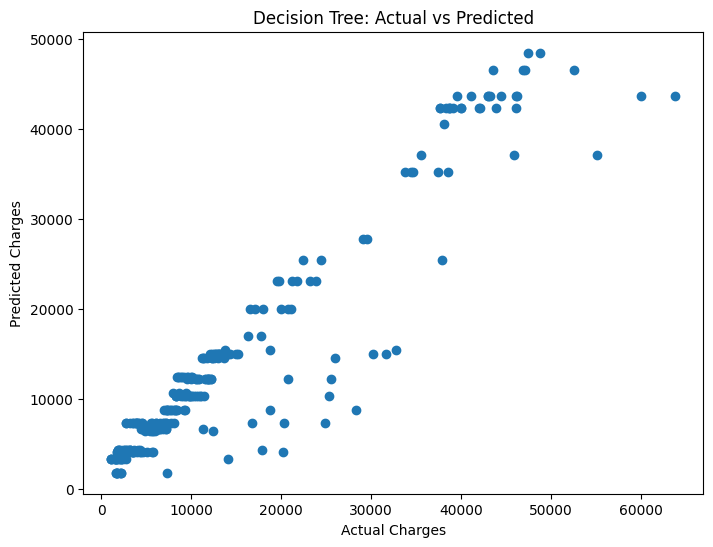

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_dt)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Decision Tree: Actual vs Predicted")
plt.show()

In [ ]:
import joblib

joblib.dump(dt_model, 'decision_tree_model.pkl')

['decision_tree_model.pkl']